[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** LIME

This file is events 1, 2, and 3. The other events are left blank here.

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | Silver | On 24 test rows, mean absolute LIME weight is highest for zip_proxy (0.135), then debt_ratio (0.082), then recent_late_payments (0.056). | Mean local R^2 was only 0.382. This is an average of local fits, not a real global importance score, and a 0/1 feature like zip_proxy can look louder than a continuous one. |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Silver | The assigned row is on the fence: P(high risk)=0.499 and the model calls it low risk. The biggest weights are zip_proxy (+0.132), debt_ratio (-0.088), and income_k (+0.060). | Local R^2 is 0.339, so the surrogate is a rough fit. It explains this row only. |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | Gold | The shortcut probe is a circle with the red corner marker. The model calls it a square at P=0.980, and 66% of the positive LIME weight sits in that marker box. A square with no marker is called a circle (P(square)=0.065). | The contrast case fit is weaker (R^2=0.546). Superpixels do not line up perfectly with the 12x12 marker, but the probe result is hard to miss. |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | TODO |  |  |
| 5. Compare Two Predictions | Why were two cases classified differently? | TODO |  |  |
| 6. Feature Interactions | Which tabular variables work together? | TODO |  |  |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | TODO |  |  |
| 8. Explain a Failure | Why did the model make this mistake? | TODO |  |  |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | TODO |  |  |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | TODO |  |  |

In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6576


epoch 2: loss=0.2582


epoch 3: loss=0.0858


epoch 4: loss=0.0955
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.986
2,contrast_square,4,1,0,0,0.065
3,failure_case,6,0,1,1,0.980


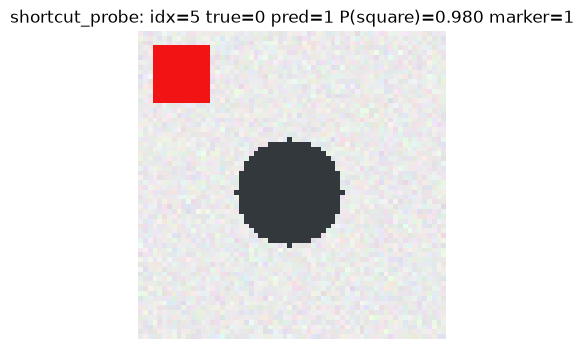

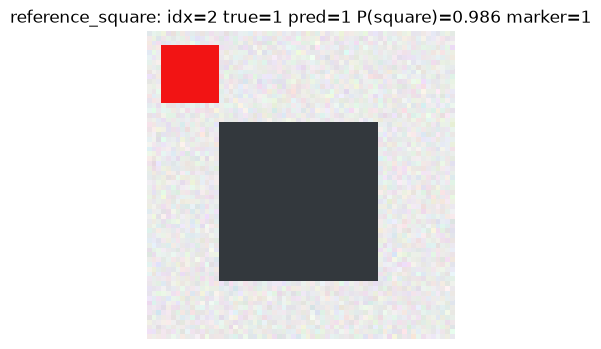

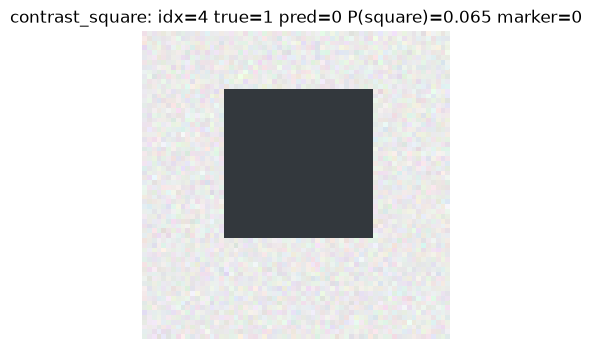

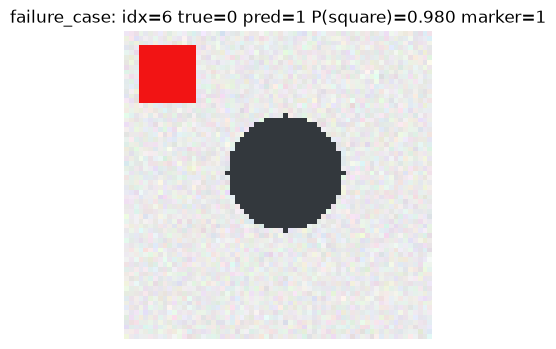

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:
# LIME helpers for events 1, 2, and 3
from lime.lime_tabular import LimeTabularExplainer
from lime import lime_image
from skimage.segmentation import slic


def make_lime_explainer(seed=SEED):
    # background rows LIME perturbs around
    return LimeTabularExplainer(
        training_data=X_train.to_numpy(),
        feature_names=feature_names,
        class_names=["low risk", "high risk"],
        mode="classification",
        discretize_continuous=True,
        random_state=seed,
    )


def explain_tabular_row(row, seed=SEED, num_samples=2000):
    row_array = np.asarray(row, dtype=float)
    explainer = make_lime_explainer(seed)
    explanation = explainer.explain_instance(
        row_array,
        predict_risk_proba,
        labels=(1,),
        num_features=len(feature_names),
        num_samples=num_samples,
    )
    # as_map is (feature index, weight). as_list is the bin rule, same order.
    mapped_rules = explanation.as_list(label=1)
    mapped_features = explanation.as_map()[1]
    weights = {
        feature_names[feature_index]: float(weight)
        for feature_index, weight in mapped_features
    }
    rules = {
        feature_names[feature_index]: rule
        for (feature_index, _), (rule, _) in zip(mapped_features, mapped_rules)
    }
    return explanation, weights, rules


def segment_image(img):
    return slic(
        np.clip(img, 0, 1),
        n_segments=36,
        compactness=10,
        start_label=0,
        channel_axis=-1,
    )


image_explainer = lime_image.LimeImageExplainer(random_state=SEED)


def explain_one_image(img, label, num_samples=700):
    return image_explainer.explain_instance(
        np.asarray(img, dtype=np.float64),
        predict_image_proba,
        labels=(int(label),),
        hide_color=0,
        num_samples=num_samples,
        batch_size=16,
        segmentation_fn=segment_image,
        random_seed=SEED,
    )


def attribution_map(explanation, label):
    segments = explanation.segments
    attr = np.zeros(segments.shape, dtype=float)
    for seg_id, weight in explanation.local_exp[int(label)]:
        attr[segments == seg_id] = weight
    return attr


# red corner marker drawn by the data generator, rows 3:15 and cols 3:15
MARKER_BOX = (slice(3, 15), slice(3, 15))


def marker_share(attr):
    positive = np.clip(attr, 0, None)
    total = float(positive.sum())
    if total <= 0:
        return 0.0
    return float(positive[MARKER_BOX].sum() / total)


print("LIME helpers are ready for events 1, 2, and 3.")

LIME helpers are ready for events 1, 2, and 3.


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Mean local R^2 across the 24 rows: 0.382


,feature,mean_abs_LIME,mean_LIME
8,zip_proxy,0.135,-0.123
2,debt_ratio,0.082,-0.017
4,recent_late_payments,0.056,-0.013
1,income_k,0.035,-0.001
9,promo_seen,0.027,-0.008
5,savings_k,0.027,0.008
3,loyalty_years,0.020,0.010
0,age,0.010,0.001
7,support_tickets,0.010,-0.004
6,app_minutes,0.007,0.003


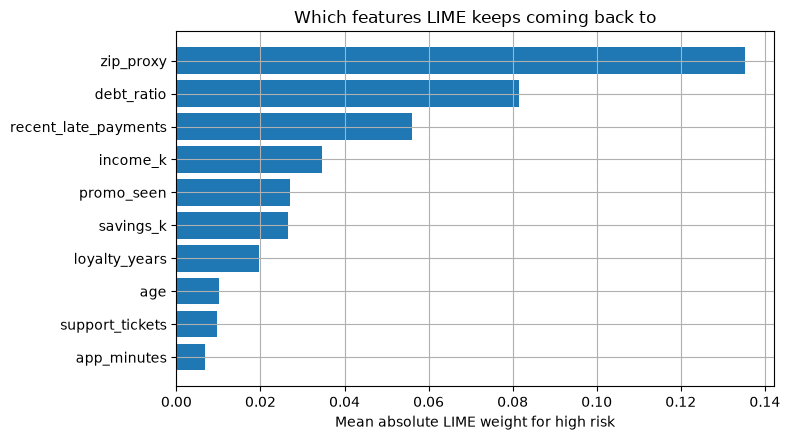

Claim: zip_proxy has the largest average |LIME| weight, then debt_ratio.
Evidence quality: The ranking is repeated local evidence, so I would not call it a true global importance. Medal: Silver.


In [9]:
# Event 1: rank features by average |LIME weight| on 24 test rows
# LIME is local, so this is a bunch of local fits, not a built-in global importance.
event1_rows = X_test.sample(n=24, random_state=SEED).reset_index(drop=True)
event1_records = []
for row_index, row in event1_rows.iterrows():
    explanation, weights, _ = explain_tabular_row(row, seed=SEED + int(row_index), num_samples=1200)
    record = {name: weights[name] for name in feature_names}
    record["local_r2"] = float(explanation.score)
    event1_records.append(record)

event1_details = pd.DataFrame(event1_records)
event1_rank = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_LIME": [event1_details[name].abs().mean() for name in feature_names],
    "mean_LIME": [event1_details[name].mean() for name in feature_names],
}).sort_values("mean_abs_LIME", ascending=False)

print(f"Mean local R^2 across the 24 rows: {event1_details['local_r2'].mean():.3f}")
display(event1_rank.round(3))

plot_rank = event1_rank.sort_values("mean_abs_LIME")
plt.figure(figsize=(8, 4.5))
plt.barh(plot_rank["feature"], plot_rank["mean_abs_LIME"])
plt.xlabel("Mean absolute LIME weight for high risk")
plt.title("Which features LIME keeps coming back to")
plt.tight_layout()
plt.show()

top_feature = event1_rank.iloc[0]["feature"]
second_feature = event1_rank.iloc[1]["feature"]
print(f"Claim: {top_feature} has the largest average |LIME| weight, then {second_feature}.")
print(
    "Evidence quality: The ranking is repeated local evidence, so I would not call it a true global importance. Medal: Silver."
)

## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

tabular_local_case index=718, pred=0, P(high risk)=0.499, local R^2=0.339


,feature,value,LIME_weight,rule
8,zip_proxy,1.000,0.132,zip_proxy > 0.00
2,debt_ratio,0.281,-0.088,0.18 < debt_ratio <= 0.28
1,income_k,48.897,0.060,income_k <= 55.14
4,recent_late_payments,2.000,0.034,1.00 < recent_late_payments <= 2.00
3,loyalty_years,8.981,-0.032,loyalty_years > 8.41
5,savings_k,1.147,0.031,savings_k <= 6.19


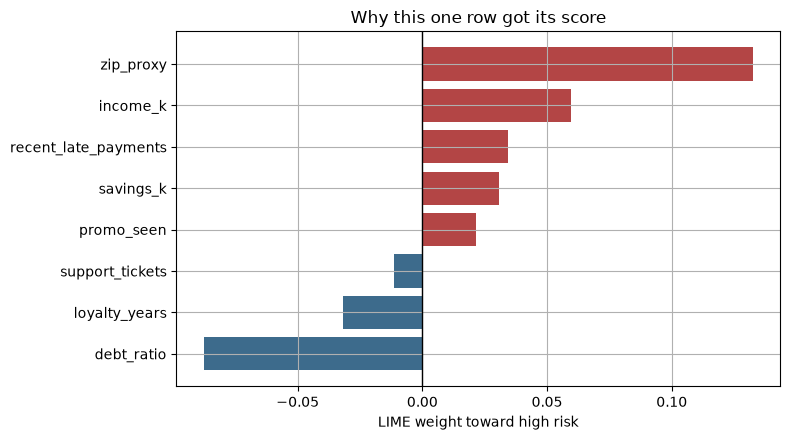

Claim: This row is a near tie, and the biggest pulls are zip_proxy, debt_ratio, income_k.
Evidence quality: LIME is built for one row, but this fit is weak. Local R^2=0.339. Medal: Silver.


In [10]:
# Event 2: explain the assigned local row
local_row = X_test.iloc[tabular_local_case]
local_prob = float(tabular_proba[tabular_local_case])
local_pred = int(tabular_pred[tabular_local_case])
local_explanation, local_weights, local_rules = explain_tabular_row(
    local_row, seed=SEED + 22, num_samples=4000
)

event2 = pd.DataFrame({
    "feature": feature_names,
    "value": [local_row[name] for name in feature_names],
    "LIME_weight": [local_weights[name] for name in feature_names],
    "rule": [local_rules[name] for name in feature_names],
})
event2["abs_weight"] = event2["LIME_weight"].abs()
event2 = event2.sort_values("abs_weight", ascending=False)

print(
    f"tabular_local_case index={tabular_local_case}, "
    f"pred={local_pred}, P(high risk)={local_prob:.3f}, "
    f"local R^2={local_explanation.score:.3f}"
)
display(event2.drop(columns="abs_weight").head(6).round(3))

plot2 = event2.head(8).sort_values("LIME_weight")
plt.figure(figsize=(8, 4.5))
colors = ["#b34545" if w > 0 else "#3d6b8c" for w in plot2["LIME_weight"]]
plt.barh(plot2["feature"], plot2["LIME_weight"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("LIME weight toward high risk")
plt.title("Why this one row got its score")
plt.tight_layout()
plt.show()

top3 = ", ".join(event2.head(3)["feature"].tolist())
print(f"Claim: This row is a near tie, and the biggest pulls are {top3}.")
medal2 = "Silver" if local_explanation.score < 0.5 else "Gold"
print(
    f"Evidence quality: LIME is built for one row, but this fit is weak. Local R^2={local_explanation.score:.3f}. Medal: {medal2}."
)

## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

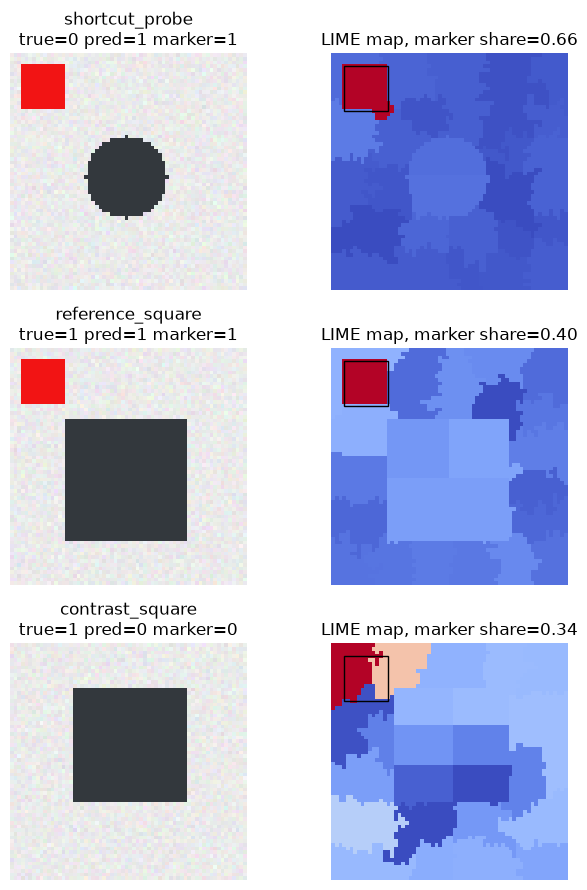

,case,true_label,marker,pred,P_square,positive_weight_in_marker_box,local_r2
0,shortcut_probe,0,1,1,0.980,0.661,0.954
1,reference_square,1,1,1,0.986,0.402,0.787
2,contrast_square,1,0,0,0.065,0.336,0.546


Claim: The shortcut probe is true class 0 but predicted 1, and 66% of the positive LIME weight is in the red marker box.
Evidence quality: That box is only 12 by 12 pixels, so 66% of the positive weight there means the local fit is on the marker. Medal: Gold.


In [11]:
# Event 3: does the image model lean on the red corner marker?
# shortcut_probe is a circle that still has the marker.
# reference_square has the marker. contrast_square does not.
event3_cases = [
    ("shortcut_probe", int(image_shortcut_case)),
    ("reference_square", int(image_reference_case)),
    ("contrast_square", int(image_contrast_case)),
]

fig, axes = plt.subplots(len(event3_cases), 2, figsize=(7, 9))
event3_rows = []
for row_i, (case_name, idx) in enumerate(event3_cases):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    pred = int(probs.argmax())
    explanation = explain_one_image(test_imgs[idx], pred, num_samples=700)
    attr = attribution_map(explanation, pred)
    share = marker_share(attr)
    event3_rows.append({
        "case": case_name,
        "true_label": int(test_y[idx]),
        "marker": int(test_marker[idx]),
        "pred": pred,
        "P_square": float(probs[1]),
        "positive_weight_in_marker_box": share,
        "local_r2": float(explanation.score),
    })
    axes[row_i, 0].imshow(test_imgs[idx])
    axes[row_i, 0].set_title(f"{case_name}\ntrue={int(test_y[idx])} pred={pred} marker={int(test_marker[idx])}")
    axes[row_i, 0].axis("off")
    show = axes[row_i, 1].imshow(attr, cmap="coolwarm")
    axes[row_i, 1].add_patch(plt.Rectangle((3, 3), 12, 12, fill=False, edgecolor="black", linewidth=1))
    axes[row_i, 1].set_title(f"LIME map, marker share={share:.2f}")
    axes[row_i, 1].axis("off")

plt.tight_layout()
plt.show()

event3_table = pd.DataFrame(event3_rows)
display(event3_table.round(3))
shortcut_share = float(event3_table.loc[event3_table["case"] == "shortcut_probe", "positive_weight_in_marker_box"].iloc[0])
shortcut_pred = int(event3_table.loc[event3_table["case"] == "shortcut_probe", "pred"].iloc[0])
true_shortcut = int(test_y[image_shortcut_case])
print(
    f"Claim: The shortcut probe is true class {true_shortcut} but predicted {shortcut_pred}, "
    f"and {shortcut_share:.0%} of the positive LIME weight is in the red marker box."
)
medal3 = "Gold" if shortcut_share >= 0.5 and shortcut_pred != true_shortcut else "Silver"
print(
    f"Evidence quality: That box is only 12 by 12 pixels, so {shortcut_share:.0%} of the positive weight there means the local fit is on the marker. Medal: {medal3}."
)

## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [12]:
# Event 4 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [13]:
# Event 5 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [14]:
# Event 6 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [15]:
# Event 7 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [16]:
# Event 8 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [17]:
# Event 9 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [18]:
# Event 10 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


# Final Model Profile

This file only runs events 1, 2, and 3 with LIME.

**Tabular model strategy:**
From 24 local explanations, zip_proxy comes out first (mean absolute weight 0.135), then debt_ratio (0.082) and recent_late_payments (0.056). I don't fully trust that order, because the average local R^2 was 0.382 and zip_proxy is a 0/1 feature, so LIME can give it a big jump. On the assigned local row the model is stuck at P(high risk)=0.499. zip_proxy pushes that row toward high risk (+0.132) and debt_ratio pushes it back down (-0.088).

**Image model strategy:**
Yes, the image model is using the red corner marker. The shortcut probe is a circle with the marker, and the model is 0.980 sure it is a square. About 66% of the positive LIME weight for that prediction is inside the marker box. The square with no marker gets called a circle (P(square)=0.065). Test accuracy on the balanced-marker set was about 0.49, which fits a model that followed the marker instead of the shape.

**Your method's decathlon profile:**
Event 2 is the kind of question LIME is for, but this particular row had a weak fit (R^2=0.339), so I marked it Silver. Event 1 is Silver too: repeating LIME gives a ranking, and it is still not a global importance method. Event 3 is the clean Gold. The image explainer put the weight on the marker, and the prediction was wrong in the way a shortcut would be wrong.

**Open questions:**
I would want permutation importance or SHAP next to the zip_proxy ranking, and a Grad-CAM map next to the marker box, to see if another method lands in the same corner.
